# Predicting base-Kissat runtime parameters using AIG representations

In [1]:
import torch
# from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv
import torch_geometric.nn as gnn
from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader

In [2]:
from pathlib import Path

data_raw_path = Path('/home/krishnendu/Research/fv-invariant-mining/smac-output-copies')

def generate_data(filename: str):
	with open(data_raw_path/filename, "r") as f:
		content = f.read()
	
	regular_time = -1.
	items = []
	for line in content.split('\n'):
		if "Regular" in line: # Regular time: TIME
			regular_time = float(line.split()[-1])
		elif "--decay" in line:
			e = [-1., -1, -1, -1]
			comps = line.split()
			e[0] = float(comps[0])
			e[1] = int(comps[1].removeprefix('--decay='))
			e[2] = int(comps[2].removeprefix('--eliminateeffort='))
			e[3] = int(comps[3].removeprefix('--stable='))
			items.append(e)
		else:
			continue
	
	items.append([regular_time, 50, 100, 1])
	return regular_time, items

In [ ]:
generate_data('miter_mult_11bit')

(411.64,
 [[721.47, 50, 1200, 0],
  [361.86, 110, 600, 2],
  [508.44, 160, 1900, 1],
  [378.93, 1, 300, 1],
  [278.12, 30, 1700, 2],
  [713.4, 200, 100, 0],
  [328.22, 150, 1400, 2],
  [486.0, 90, 800, 1],
  [358.82, 80, 1800, 2],
  [458.8, 130, 400, 1],
  [335.85, 40, 1600, 2],
  [266.94, 20, 1600, 2],
  [267.84, 20, 1800, 2],
  [230.51, 1, 1800, 2],
  [327.26, 40, 1800, 2],
  [224.84, 1, 1600, 2],
  [324.56, 40, 1700, 2],
  [322.97, 40, 1900, 2],
  [222.27, 1, 1300, 2],
  [259.2, 10, 1600, 2],
  [379.78, 1, 1000, 1],
  [722.77, 180, 1100, 0],
  [416.7, 70, 1700, 1],
  [223.33, 1, 1100, 2],
  [223.4, 1, 1700, 2],
  [223.11, 1, 1200, 2],
  [724.49, 1, 1300, 0],
  [722.89, 10, 1400, 0],
  [411.64, 50, 100, 1]])

In [3]:
from typing import List, Tuple
from aig_grapher import AIG
from setup import aag_path

decay_max = 200
eliminateeffort_max = 2000

class PyGSATDataset(Dataset):
	def __init__(self, data_paths: List[str], aig_paths: List[str | Path], root=None, transform=None, pre_transform=None):
		# PyG Datasets take root, transform, and pre_transform args
		super().__init__(root, transform, pre_transform)
		self.aigs = []
		self.data = []

		self._load_data(data_paths, aig_paths)
		
	def _load_data(self, data_paths: List[str], aig_paths: List[str | Path]):
		for i in range(len(data_paths)):
			reg_time, e = generate_data(data_paths[i])
			for j in range(len(e)):
				e[j][0] = (reg_time - e[j][0]) / reg_time # stores percentage improvement
				e[j][1] /= decay_max
				e[j][2] /= eliminateeffort_max
			self.data.extend(e)
			self.aigs.extend([aig_paths[i] for _ in range(len(e))])
	
	def len(self):
		# PyG requires overriding `len()` instead of `__len__()`
		return len(self.data)

	def get(self, idx):
		# PyG requires overriding `get()` instead of `__getitem__()`
		
		# Load AIG
		aig_path = self.aigs[idx]
		aig = AIG(aag_path / aig_path)
		edges, edge_typ, node_typ, num_inv_preds, out_is_inv = aig.to_graph_data()

		# Load parameter data
		d = self.data[idx]
		label = d[0]
		stbl_cls = d[3]
		feats = d[1:3]

		# Construct the PyG Data object
		# Note: PyG expects edge_index to be shape [2, num_edges]. 
		# I removed the outer brackets `[edges]` from your original code to prevent an unwanted batch dimension [1, 2, E].
		# If your `edges` variable is shape [num_edges, 2], you will need to add `.t().contiguous()` to it.
		data = Data(
			edge_index=torch.tensor(edges, dtype=torch.long),
			edge_attr=torch.tensor(edge_typ, dtype=torch.long),  # Standard PyG key for edge features
			
			# Custom graph features (PyG allows arbitrary kwargs)
			node_typ=torch.tensor(node_typ, dtype=torch.long),
			num_inverted_predecessors=torch.tensor(num_inv_preds, dtype=torch.long),
			out_is_inv=torch.tensor([int(out_is_inv)], dtype=torch.float),
			stbl_cls=torch.tensor([stbl_cls], dtype=torch.long),
			feats=torch.tensor([feats], dtype=torch.float),      # Cast to float for standard PyG features
			
			# Standard PyG key for labels
			# Note: You originally cast 'label' (a percentage float) to torch.long. 
			# I changed this to torch.float to prevent your percentages from rounding to 0, 
			# but change it back to torch.long if you are discretizing them into classes elsewhere.
			y=torch.tensor([label], dtype=torch.float)           
		)

		return data
		

In [4]:
fns = ['miter_mult_8bit', 'miter_mult_9bit', 'miter_mult_10bit']
ds = PyGSATDataset(fns, [f"{f}.aag" for f in fns])

sample_data = ds[0]
sample_data

Data(edge_index=[2, 2560], edge_attr=[2560], y=[1], node_typ=[1298], num_inverted_predecessors=[1298], out_is_inv=[1], stbl_cls=[1], feats=[1, 2])

In [5]:
dl = DataLoader(ds, 1)

In [6]:
class Predictor(nn.Module):
	def __init__(self, hidden_dim=64):
		super().__init__()
# =========================
		# GCN Layer Declaration
		# =========================
		self.gcn1 = GCNConv(5, hidden_dim)
		self.gcn2 = GCNConv(hidden_dim, hidden_dim)

		# =========================
		# Node Embedding & Conv Layer Declaration
		# =========================
		self.stbl_emb = nn.Embedding(3, 3)  # 3 stable types, embed to dim 3
		self.conv_k12 = nn.Conv1d(1, 1, kernel_size=12, stride=3)  # (60-12)//3+1 = 17 (F = inputshape - kernelsize / stride) + 1
		self.conv_k15 = nn.Conv1d(1, 1, kernel_size=15, stride=3)  # (60-15)//3+1 = 16

		# =========================
		# Final MLP
		# =========================
		self.mlp = nn.Sequential(
			nn.Linear(hidden_dim + 6, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 1)
		)
		
	def forward(self, data):
		"""
		data.batch must exist if using DataLoader
		"""
		# =========================
		# Build Node Features
		# =========================
		# node_type → one-hot
		node_type = F.one_hot(
			data.node_typ.long(),
			num_classes=4
		).float()

		# num_inverted_predecessors
		inv_pred = data.num_inverted_predecessors.view(-1, 1).float() # since node_type → shape (num_nodes, 4) but inv_pred is (num_nodes,) → reshape to (num_nodes, 1) for concatenation

		# concatenate → (num_nodes, 5)
		x = torch.cat([node_type, inv_pred], dim=-1)

		# =========================
		# GCN Forward
		# =========================

		x = F.relu(self.gcn1(x, data.edge_index))
		x = F.relu(self.gcn2(x, data.edge_index))

		# graph-level embedding
		x = gnn.pool.global_mean_pool(x, data.batch) #shape after: [batch_size, hidden_dim]
		# =========================
		# Parameters embed
		# =========================

		stbl = self.stbl_emb(data.stbl_cls)
		out_inv = data.out_is_inv.unsqueeze(1)
		# print(stbl.shape, out_inv.shape, data.feats.shape)
		params_emb = torch.cat((stbl, out_inv, data.feats), dim=1)
		glob = torch.cat((x, params_emb), dim=1)
		# print(glob.shape)
		
		out = self.mlp(glob) # [batch, 1]

		return out.squeeze(1) # [batch]

In [7]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

model = Predictor().to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
from tqdm.notebook import tqdm

dataloader = DataLoader(ds, batch_size=4, shuffle=True)

for epoch in tqdm(range(1000)):
	total_loss = 0
	for data in dataloader:
		data = data.to(device)
		optimizer.zero_grad() # Reset gradients to zero

		output = model(data)           # forward pass
		loss = criterion(output, data.y) # compute loss

		loss.backward() # compute gradients
		optimizer.step() # update parameters

		total_loss += loss.item()
	print(f"Loss at epoch {epoch}: {total_loss}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Loss at epoch 0: 3.01992314402014
Loss at epoch 1: 1.4338869443163276
Loss at epoch 2: 1.1797284374188166
Loss at epoch 3: 0.9679092908045277
Loss at epoch 4: 0.9533260078169405
Loss at epoch 5: 0.9553097116295248
Loss at epoch 6: 0.9834631757985335
Loss at epoch 7: 0.8987956558121368
Loss at epoch 8: 0.9075137804611586
Loss at epoch 9: 1.0037412636447698
Loss at epoch 10: 0.943178943474777
Loss at epoch 11: 0.9495098748011515
Loss at epoch 12: 0.9620771908666939
Loss at epoch 13: 0.8630289901047945
Loss at epoch 14: 0.879977441392839
Loss at epoch 15: 0.9215420228429139
Loss at epoch 16: 0.8615159831970232
Loss at epoch 17: 0.8826480614952743
Loss at epoch 18: 0.8627620140323415
Loss at epoch 19: 0.8634602358797565
Loss at epoch 20: 0.8415865293936804
Loss at epoch 21: 0.8175472874427214
Loss at epoch 22: 0.8097919105784968
Loss at epoch 23: 0.8697889839531854
Loss at epoch 24: 0.8585474088322371
Loss at epoch 25: 0.8516148432972841
Loss at epoch 26: 0.8101642139663454
Loss at epoch 2

KeyboardInterrupt: 

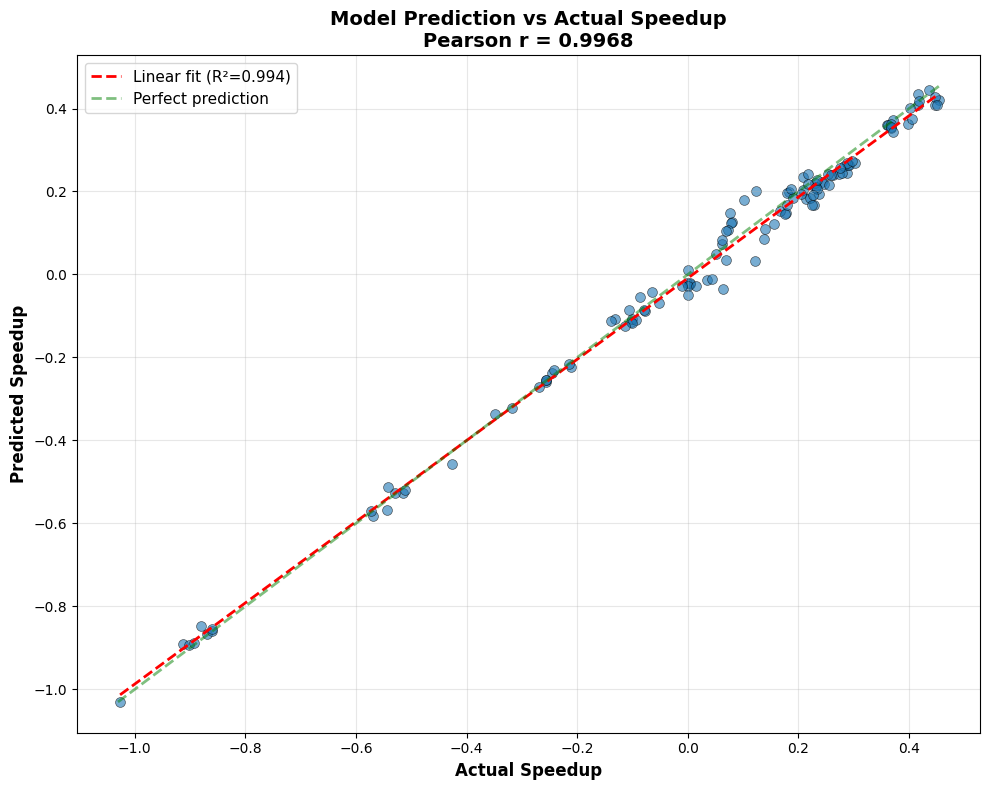

Correlation coefficient (Pearson r): 0.9968
R² value: 0.9936
Mean Absolute Error: 0.0230
RMSE: 0.0297


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Get predictions on entire dataset
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for data in dataloader:
        data = data.to(device)
        output = model(data)
        predictions.extend(output.cpu().numpy())
        actuals.extend(data.y.cpu().numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Calculate correlation
correlation = np.corrcoef(predictions, actuals)[0, 1]
slope, intercept, r_value, p_value, std_err = stats.linregress(actuals, predictions)

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(actuals, predictions, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

# Add regression line
x_line = np.array([actuals.min(), actuals.max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit (R²={r_value**2:.3f})')

# Add perfect prediction line (y=x)
lim = [min(actuals.min(), predictions.min()), max(actuals.max(), predictions.max())]
ax.plot(lim, lim, 'g--', linewidth=2, alpha=0.5, label='Perfect prediction')

# Labels and formatting
ax.set_xlabel('Actual Speedup', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Speedup', fontsize=12, fontweight='bold')
ax.set_title(f'Model Prediction vs Actual Speedup\nPearson r = {correlation:.4f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Correlation coefficient (Pearson r): {correlation:.4f}")
print(f"R² value: {r_value**2:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(predictions - actuals)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((predictions - actuals)**2)):.4f}")

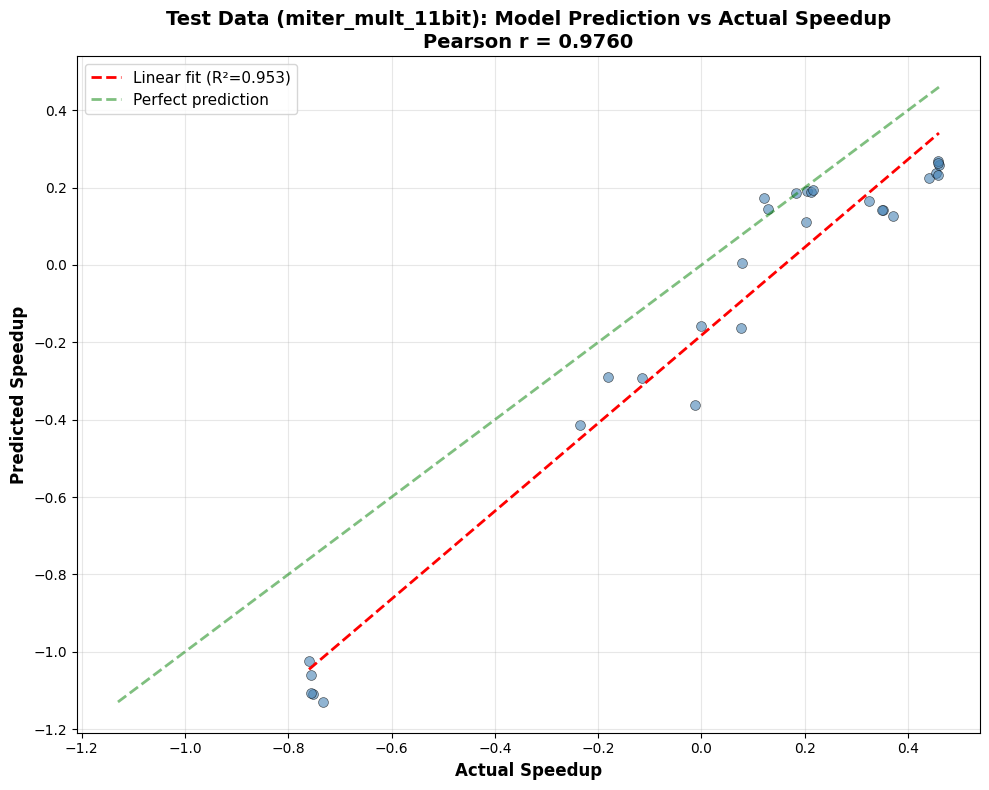


TEST DATA: miter_mult_11bit
Correlation coefficient (Pearson r): 0.9760
R² value: 0.9526
Mean Absolute Error: 0.1809
RMSE: 0.2117
Number of test samples: 29


In [10]:
# Test on miter_mult_11bit
test_fns = ['miter_mult_11bit']
test_ds = PyGSATDataset(test_fns, [f"{f}.aag" for f in test_fns])
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False)

# Get predictions on test dataset
model.eval()
test_predictions = []
test_actuals = []

with torch.no_grad():
    for data in test_dl:
        data = data.to(device)
        output = model(data)
        test_predictions.extend(output.cpu().numpy())
        test_actuals.extend(data.y.cpu().numpy())

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

# Calculate correlation for test data
test_correlation = np.corrcoef(test_predictions, test_actuals)[0, 1]
test_slope, test_intercept, test_r_value, test_p_value, test_std_err = stats.linregress(test_actuals, test_predictions)

# Create scatter plot for test data
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(test_actuals, test_predictions, alpha=0.6, s=50, edgecolors='k', linewidth=0.5, color='steelblue')

# Add regression line
x_line = np.array([test_actuals.min(), test_actuals.max()])
y_line = test_slope * x_line + test_intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit (R²={test_r_value**2:.3f})')

# Add perfect prediction line (y=x)
lim = [min(test_actuals.min(), test_predictions.min()), max(test_actuals.max(), test_predictions.max())]
ax.plot(lim, lim, 'g--', linewidth=2, alpha=0.5, label='Perfect prediction')

# Labels and formatting
ax.set_xlabel('Actual Speedup', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Speedup', fontsize=12, fontweight='bold')
ax.set_title(f'Test Data (miter_mult_11bit): Model Prediction vs Actual Speedup\nPearson r = {test_correlation:.4f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for test data
print(f"\n{'='*60}")
print(f"TEST DATA: miter_mult_11bit")
print(f"{'='*60}")
print(f"Correlation coefficient (Pearson r): {test_correlation:.4f}")
print(f"R² value: {test_r_value**2:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(test_predictions - test_actuals)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((test_predictions - test_actuals)**2)):.4f}")
print(f"Number of test samples: {len(test_actuals)}")
print(f"{'='*60}")

Fine-tuning model on 1 sample from miter_mult_11bit...
Fine-tune epoch 0: Loss = 0.1280
Fine-tune epoch 10: Loss = 0.0063
Fine-tune epoch 20: Loss = 0.0005
Fine-tune epoch 30: Loss = 0.0007
Fine-tune epoch 40: Loss = 0.0001
Fine-tuning complete!

Evaluating fine-tuned model on miter_mult_11bit...


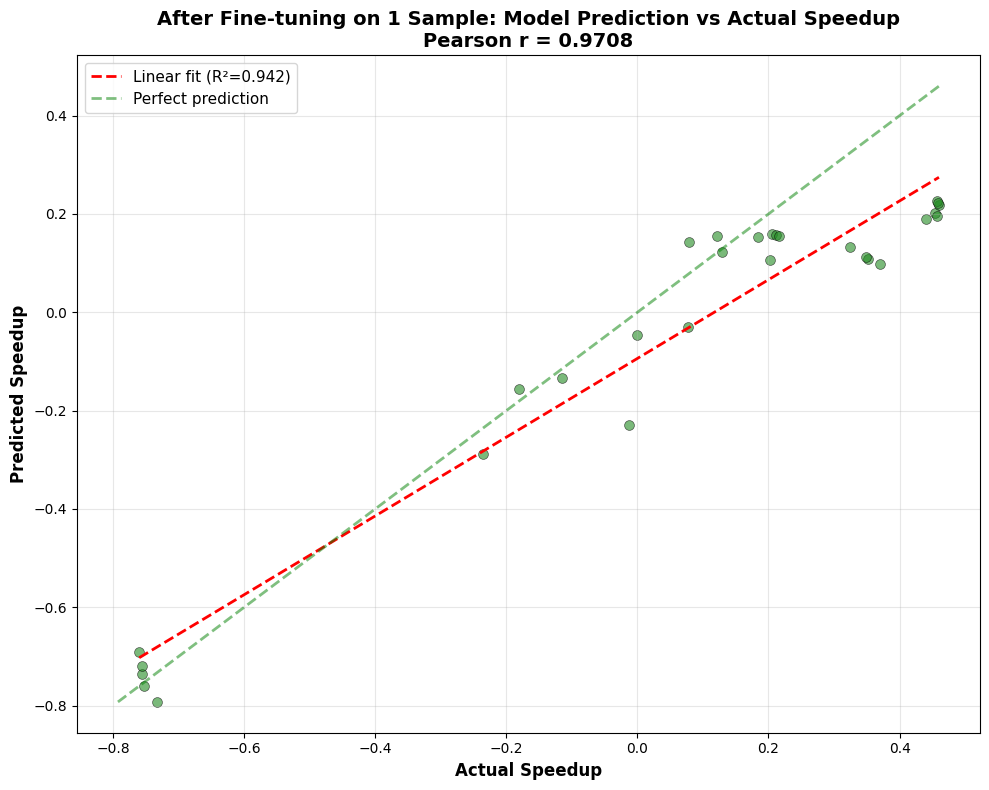


AFTER FINE-TUNING ON 1 SAMPLE (miter_mult_11bit)
Correlation coefficient (Pearson r): 0.9708
R² value: 0.9424
Mean Absolute Error: 0.1196
RMSE: 0.1539
Number of test samples: 29

IMPROVEMENT FROM BEFORE:
Correlation improvement: -0.0053
R² improvement: -0.0103


In [12]:
# Fine-tune on one sample from miter_mult_11bit
print("Fine-tuning model on 1 sample from miter_mult_11bit...")

finetune_fns = ['miter_mult_11bit']
finetune_ds = PyGSATDataset(finetune_fns, [f"{f}.aag" for f in finetune_fns])

# Create a dataloader with just the first sample
finetune_single_dl = DataLoader([finetune_ds[0]], batch_size=1, shuffle=False)

# Train on first sample only
model.train()
for epoch in range(50):  # 50 epochs of fine-tuning
    for data in finetune_single_dl:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Fine-tune epoch {epoch}: Loss = {loss.item():.4f}")

print("Fine-tuning complete!")

# Now evaluate on all miter_mult_11bit samples after fine-tuning
print("\nEvaluating fine-tuned model on miter_mult_11bit...")
finetune_dl = DataLoader(finetune_ds, batch_size=4, shuffle=False)

model.eval()
finetune_predictions = []
finetune_actuals = []

with torch.no_grad():
    for data in finetune_dl:
        data = data.to(device)
        output = model(data)
        finetune_predictions.extend(output.cpu().numpy())
        finetune_actuals.extend(data.y.cpu().numpy())

finetune_predictions = np.array(finetune_predictions)
finetune_actuals = np.array(finetune_actuals)

# Calculate correlation after fine-tuning
finetune_correlation = np.corrcoef(finetune_predictions, finetune_actuals)[0, 1]
finetune_slope, finetune_intercept, finetune_r_value, finetune_p_value, finetune_std_err = stats.linregress(finetune_actuals, finetune_predictions)

# Create scatter plot after fine-tuning
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(finetune_actuals, finetune_predictions, alpha=0.6, s=50, edgecolors='k', linewidth=0.5, color='forestgreen')

# Add regression line
x_line = np.array([finetune_actuals.min(), finetune_actuals.max()])
y_line = finetune_slope * x_line + finetune_intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit (R²={finetune_r_value**2:.3f})')

# Add perfect prediction line (y=x)
lim = [min(finetune_actuals.min(), finetune_predictions.min()), max(finetune_actuals.max(), finetune_predictions.max())]
ax.plot(lim, lim, 'g--', linewidth=2, alpha=0.5, label='Perfect prediction')

# Labels and formatting
ax.set_xlabel('Actual Speedup', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Speedup', fontsize=12, fontweight='bold')
ax.set_title(f'After Fine-tuning on 1 Sample: Model Prediction vs Actual Speedup\nPearson r = {finetune_correlation:.4f}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics after fine-tuning
print(f"\n{'='*60}")
print(f"AFTER FINE-TUNING ON 1 SAMPLE (miter_mult_11bit)")
print(f"{'='*60}")
print(f"Correlation coefficient (Pearson r): {finetune_correlation:.4f}")
print(f"R² value: {finetune_r_value**2:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(finetune_predictions - finetune_actuals)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((finetune_predictions - finetune_actuals)**2)):.4f}")
print(f"Number of test samples: {len(finetune_actuals)}")
print(f"{'='*60}")
print(f"\nIMPROVEMENT FROM BEFORE:")
print(f"Correlation improvement: {finetune_correlation - test_correlation:.4f}")
print(f"R² improvement: {finetune_r_value**2 - test_r_value**2:.4f}")

In [9]:
# Create parameter grid and run through model to find best parameters
import itertools
import pandas as pd

print("Generating parameter grid for miter_mult_11bit...")

# Parameter ranges
decay_vals = list(range(1, 201))  # 1..200
eliminateeffort_vals = list(range(0, 2001, 100))  # 0..2000 in steps of 100 for reasonable grid size
stable_vals = [0, 1, 2]

# Get AIG data for miter_mult_11bit
aig_path_11bit = aag_path / "miter_mult_11bit.aag"
aig = AIG(aig_path_11bit)
edges, edge_typ, node_typ, num_inv_preds, out_is_inv = aig.to_graph_data()

# Create base PyG data object (graph features are constant)
base_data = Data(
    edge_index=torch.tensor(edges, dtype=torch.long),
    edge_attr=torch.tensor(edge_typ, dtype=torch.long),
    node_typ=torch.tensor(node_typ, dtype=torch.long),
    num_inverted_predecessors=torch.tensor(num_inv_preds, dtype=torch.long),
    out_is_inv=torch.tensor([int(out_is_inv)], dtype=torch.float),
)

# Generate predictions for all parameter combinations
print(f"Evaluating {len(decay_vals)} decay × {len(eliminateeffort_vals)} eliminateeffort × {len(stable_vals)} stable = {len(decay_vals) * len(eliminateeffort_vals) * len(stable_vals)} configurations...")

results = []
model.eval()

with torch.no_grad():
    for decay, eliminateeffort, stable in itertools.product(decay_vals, eliminateeffort_vals, stable_vals):
        # Normalize parameters
        decay_norm = decay / decay_max
        eliminateeffort_norm = eliminateeffort / eliminateeffort_max
        
        # Create data object with parameters
        data = Data(
            edge_index=base_data.edge_index.clone(),
            edge_attr=base_data.edge_attr.clone(),
            node_typ=base_data.node_typ.clone(),
            num_inverted_predecessors=base_data.num_inverted_predecessors.clone(),
            out_is_inv=base_data.out_is_inv.clone(),
            stbl_cls=torch.tensor([stable], dtype=torch.long),
            feats=torch.tensor([[decay_norm, eliminateeffort_norm]], dtype=torch.float),
            y=torch.tensor([0.0], dtype=torch.float),  # dummy label
            batch=torch.tensor([0], dtype=torch.long)
        )
        
        data = data.to(device)
        output = model(data)
        predicted_speedup = output.item()
        
        results.append({
            'decay': decay,
            'eliminateeffort': eliminateeffort,
            'stable': stable,
            'predicted_speedup': predicted_speedup
        })

# Convert to DataFrame for easy sorting
results_df = pd.DataFrame(results)

# Get top K=5 best parameters (sorted by predicted speedup)
top_k = 5
top_results = results_df.nlargest(top_k, 'predicted_speedup')

print(f"\n{'='*80}")
print(f"TOP {top_k} BEST PARAMETER CONFIGURATIONS FOR miter_mult_11bit")
print(f"{'='*80}")
print(top_results.to_string(index=False))
print(f"{'='*80}")

# Also show in a nice formatted way
print(f"\nDetailed Top {top_k} Parameters:\n")
for idx, row in top_results.iterrows():
    rank = idx + 1
    print(f"Rank {rank}: Predicted Speedup = {row['predicted_speedup']:.4f}")
    print(f"  --decay={int(row['decay'])} --eliminateeffort={int(row['eliminateeffort'])} --stable={int(row['stable'])}")
    print()

# Show distribution statistics
print(f"\nParameter Grid Statistics:")
print(f"  Min predicted speedup: {results_df['predicted_speedup'].min():.4f}")
print(f"  Max predicted speedup: {results_df['predicted_speedup'].max():.4f}")
print(f"  Mean predicted speedup: {results_df['predicted_speedup'].mean():.4f}")
print(f"  Median predicted speedup: {results_df['predicted_speedup'].median():.4f}")
print(f"  Std predicted speedup: {results_df['predicted_speedup'].std():.4f}")

Generating parameter grid for miter_mult_11bit...
Evaluating 200 decay × 21 eliminateeffort × 3 stable = 12600 configurations...

TOP 5 BEST PARAMETER CONFIGURATIONS FOR miter_mult_11bit
 decay  eliminateeffort  stable  predicted_speedup
     1             2000       2          60.225670
     1             1900       2          60.219650
     2             2000       2          60.214684
     1             1800       2          60.213623
     2             1900       2          60.208687

Detailed Top 5 Parameters:

Rank 63: Predicted Speedup = 60.2257
  --decay=1 --eliminateeffort=2000 --stable=2

Rank 60: Predicted Speedup = 60.2197
  --decay=1 --eliminateeffort=1900 --stable=2

Rank 126: Predicted Speedup = 60.2147
  --decay=2 --eliminateeffort=2000 --stable=2

Rank 57: Predicted Speedup = 60.2136
  --decay=1 --eliminateeffort=1800 --stable=2

Rank 123: Predicted Speedup = 60.2087
  --decay=2 --eliminateeffort=1900 --stable=2


Parameter Grid Statistics:
  Min predicted speedup: 57.